In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('df_preprocessed.csv')
df

,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,...,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,82600.0,0.9,20000.0,3,0.0,0.0,7200.0,19500.0,13200.0,...,0,3,1,1,0,0,0,1,0,0
1,38.0,21500.0,7.0,0.0,2,5100.0,0.0,1400.0,5400.0,3500.0,...,0,5,2,1,1,0,0,0,0,0
2,38.0,86100.0,5.8,0.0,4,0.0,0.0,10200.0,19400.0,6000.0,...,0,1,3,0,0,1,0,0,0,2
3,58.0,66800.0,2.2,0.0,5,11400.0,0.0,6200.0,11900.0,7900.0,...,0,3,3,0,0,0,0,0,1,2
4,48.0,57300.0,3.4,0.0,4,9400.0,21300.0,3600.0,16200.0,8100.0,...,0,3,2,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404795,27.0,32400.0,5.0,10400.0,4,2800.0,7000.0,2200.0,4900.0,6100.0,...,0,4,1,0,0,0,0,1,0,0
404796,38.0,49200.0,1.9,0.0,5,14000.0,0.0,2600.0,13600.0,8600.0,...,0,5,3,0,0,0,0,1,0,0
404797,32.0,25700.0,3.2,6300.0,1,0.0,0.0,2000.0,4600.0,2500.0,...,0,5,1,0,0,0,1,0,0,1
404798,48.0,47200.0,3.0,0.0,4,0.0,0.0,7000.0,8900.0,7200.0,...,0,5,3,0,0,0,1,0,0,2


In [3]:
X = df.drop('emi_eligibility_num', axis=1)
X.shape

(404800, 30)

In [4]:
y = df['emi_eligibility_num']
y.shape

(404800,)

In [5]:
y.value_counts()

emi_eligibility_num
0    312868
2     74444
1     17488
Name: count, dtype: int64

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [11]:
RandomForestClassifier()

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
RF = RandomForestClassifier(n_estimators=300, criterion='entropy', class_weight='balanced', n_jobs=-1 )

In [25]:
RF.fit(x_train, y_train)

,n_estimators,300
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
RF.score(x_test, y_test)

0.952346837944664

In [7]:
df_non_tree = pd.read_csv('df_transformed.csv')

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

X_1 = df_non_tree.drop('emi_eligibility_num', axis=1)
y_1 = df_non_tree['emi_eligibility_num']



In [9]:
MinMaxScaler()

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [10]:
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=21, stratify=y)



In [11]:
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
svm_ = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svm', SVC(kernel='rbf', max_iter=2000, class_weight='balanced'))
])

svm_.fit(x_train_1, y_train_1)

svm_.score(x_test_1, y_test_1)


c:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\venv_labmentix\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.7862401185770751

In [14]:
LogisticRegression()

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
logistic_ = Pipeline([
    ('scaler', MinMaxScaler()),
    ('LogisticRegression', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

logistic_.fit(x_train_1, y_train_1)

logistic_.score(x_test_1, y_test_1)

0.9469120553359683

In [16]:
XGBClassifier()

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
y.value_counts()

emi_eligibility_num
0    312868
2     74444
1     17488
Name: count, dtype: int64

In [18]:
xgb_ = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= (312868+74444+17488) / (3 * 17488),  # xgb dont have any param like class_weight like others so we use formula manually to make it balanced
    n_jobs=-1
)

In [19]:
xgb_.fit(x_train, y_train)

c:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\venv_labmentix\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:26:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
xgb_.score(x_test, y_test)

0.9815834980237154

In [27]:
y_pred_xgb = xgb_.predict(x_test)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     62574
           1       0.94      0.61      0.74      3497
           2       0.96      0.99      0.98     14889

    accuracy                           0.98     80960
   macro avg       0.96      0.87      0.90     80960
weighted avg       0.98      0.98      0.98     80960



<Axes: >

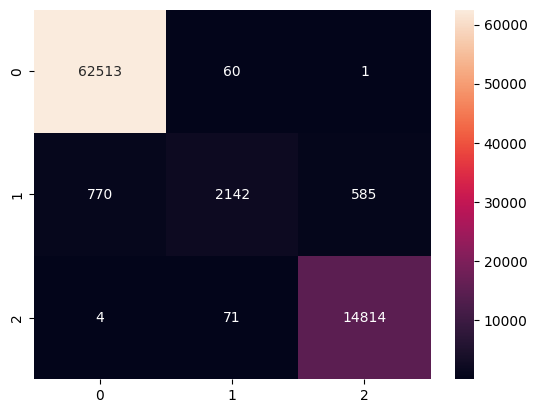

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')


In [29]:
from sklearn.utils.class_weight import compute_class_weight


In [30]:
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw))
sw = np.array([cw_dict[val] for val in y_train])

In [35]:
xgb_1 = XGBClassifier(
    objective='multi:softprob',
    num_class=len(classes),
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

xgb_1.fit(x_train, y_train, sample_weight=sw)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
xgb_1.score(x_test, y_test)

0.9503458498023716

In [37]:
y_pred_1 = xgb_1.predict(x_test)

print(classification_report(y_test, y_pred_1))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     62574
           1       0.46      0.99      0.63      3497
           2       1.00      0.92      0.96     14889

    accuracy                           0.95     80960
   macro avg       0.82      0.96      0.86     80960
weighted avg       0.98      0.95      0.96     80960



In [ ]:
import joblib
#joblib.dump(xgb_1, "xgb_clf.pkl")


['xgb_clf.pkl']

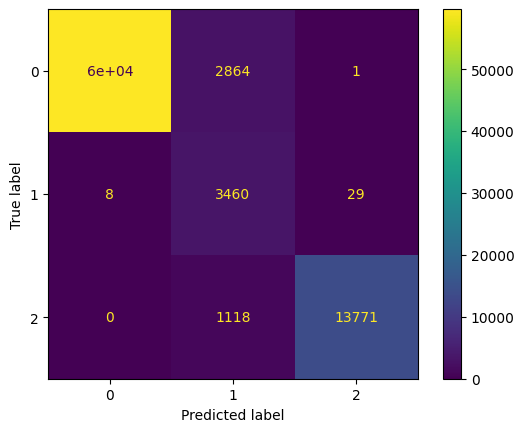

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(xgb_1, x_test, y_test)


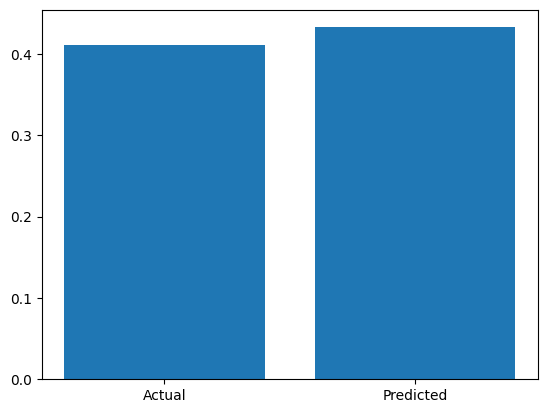

In [40]:
import matplotlib.pyplot as plt
plt.bar(["Actual", "Predicted"], [y_test.mean(), y_pred_1.mean()])
plt.show()


In [41]:
df.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'school_fees', 'college_fees', 'travel_expenses',
       'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount',
       'credit_score', 'bank_balance', 'requested_amount', 'requested_tenure',
       'max_monthly_emi', 'gender_num', 'marital_status_num', 'education_num',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'company_type_num', 'house_type_num',
       'existing_loans_num', 'emi_scenario_E-commerce Shopping EMI',
       'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI',
       'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI',
       'emi_eligibility_num'],
      dtype='object')